# 04: Regression, Matching, and Propensity Estimators

This lesson compares several estimators for the same identified causal estimand. We study what each estimator is doing, what assumptions it leans on, and why estimates can differ even when the causal graph is unchanged.

We will use one observational example dataset, one causal graph, and one target estimand: the average total effect of `feature_exposure` on `weekly_value`. Then we will estimate that target with outcome regression, propensity-score matching, propensity-score stratification, and propensity-score weighting.

## Learning Goals

By the end, you should be able to:

- Explain the difference between an estimand and an estimator.
- Run manual versions of regression, matching, stratification, and weighting estimators.
- Run the corresponding DoWhy estimators for a common backdoor estimand.
- Diagnose basic estimator behavior using propensity overlap, covariate balance, and estimate stability.
- Explain why estimator agreement is useful but does not prove the causal graph is correct.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Regression, Matching, And Propensity Estimators**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, or anomaly indicators are named to mirror applied causal workflows rather than abstract textbook variables. The experiment uses propensity scores as a design diagnostic as much as an estimator. Overlap and balance determine whether the causal contrast is credible.

The simulation is not meant to make the problem easy. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

For binary treatment, the average treatment effect is

$$
\tau=\mathbb{E}\{Y(1)-Y(0)\}.
$$

Under conditional exchangeability, positivity, and consistency,

$$
\tau=\mathbb{E}_X\left[\mathbb{E}(Y\mid D=1,X)-\mathbb{E}(Y\mid D=0,X)\right].
$$

Matching, regression, and weighting are different computational routes to this adjusted contrast.





## Tutorial Workflow

### Estimand versus Estimator

The **estimand** is the causal quantity implied by the graph and assumptions. In this lesson, the estimand is the average treatment effect after adjusting for observed common causes.

The **estimator** is the statistical method used to compute that estimand from finite data. Regression, matching, stratification, and weighting can all target the same estimand, but they do so with different statistical machinery.

#### Setup

This setup cell imports the packages used in the notebook, creates output folders, fixes a random seed, and suppresses known third-party compatibility warnings. The warning policy keeps expected library chatter out of the student-facing notebook while preserving real execution errors.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import platform
import sys
import warnings

START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [START_DIR, *START_DIR.parents] if (candidate / "pyproject.toml").exists()),
    START_DIR,
)

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = PROJECT_ROOT / ".cache" / "matplotlib"

for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR))

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__

    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise

    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import dowhy
from dowhy import CausalModel

RANDOM_SEED = 41
rng = np.random.default_rng(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")

print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")
print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Python executable: /home/apex/Documents/portfolio/.venv/bin/python
Python version: 3.11.15
DoWhy version: 0.12
Notebook directory: /home/apex/Documents/portfolio/notebooks/tutorials/dowhy
Output directory: /home/apex/Documents/portfolio/notebooks/tutorials/dowhy/outputs


The notebook is ready if this step prints a DoWhy version. All generated outputs from this lesson use a `04_` prefix.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Estimator Map

Before creating data, it helps to name the estimator families. This table gives a student-friendly summary of what each method is trying to do.

| estimator_family | basic_idea | main_strength | main_failure_mode |
| --- | --- | --- | --- |
| Outcome regression | Model the outcome as a function of treatment and confounders. | Simple and interpretable when the outcome model is credible. | Can be biased if the outcome model is misspecified. |
| Propensity-score matching | Compare treated and untreated units with similar treatment probabilities. | Makes treated-control comparability intuitive. | Can be noisy or biased when matches are poor or overlap is weak. |
| Propensity-score stratification | Compare treated and untreated units within propensity-score strata. | Easy to inspect and explain. | Sensitive to bin choices and sparse cells. |
| Propensity-score weighting | Reweight units by inverse treatment probability to reduce observed confounding. | Targets population-level effects directly when propensities are reliable. | Extreme weights can create high variance and fragile estimates. |


All four methods still rely on the same causal assumption: after adjusting for observed common causes, treatment is as-if randomized. The estimator does not rescue a wrong graph.

#### Causal Question and Variable Roles

The teaching question is:

> What is the average total effect of `feature_exposure` on `weekly_value`?

The variables below are all pre-treatment common causes except the treatment, outcome, and simulation-only treatment probability.

| variable | role | timing | used_for_adjustment |
| --- | --- | --- | --- |
| feature_exposure | treatment | treatment time | no; this is the treatment |
| weekly_value | outcome | future outcome window | no; this is the outcome |
| user_engagement | observed common cause | pre-treatment | yes |
| prior_sessions | observed common cause | pre-treatment | yes |
| account_age_weeks | observed common cause | pre-treatment | yes |
| is_power_user | observed common cause | pre-treatment | yes |
| baseline_value | observed common cause | pre-treatment | yes |
| treatment_probability | simulation diagnostic | known only because this is simulated | no; not a real observed column |


The adjustment set is deliberately straightforward: all adjustment variables are pre-treatment common causes. This lets the notebook focus on estimator mechanics rather than bad-control mistakes.

#### Create an Example Dataset

This dataset is observational: treatment assignment depends on baseline variables. The true effect is constant and known because this is a simulation. That gives us a benchmark for comparing estimators.

In [2]:
# Define reusable helpers for the Create An Example Dataset section.
def make_estimator_teaching_data(n=4_500, seed=41):
    """
    Idea: Construct the estimator example data used in the Create An Example Dataset section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, true_ate.
    """
    local_rng = np.random.default_rng(seed)

    user_engagement = local_rng.normal(loc=0.0, scale=1.0, size=n)
    prior_sessions = np.clip(
        local_rng.poisson(lam=np.exp(1.0 + 0.23 * user_engagement), size=n),
        0,
        30,
    )
    account_age_weeks = local_rng.gamma(shape=2.2, scale=3.5, size=n)
    is_power_user = local_rng.binomial(
        n=1,
        p=1 / (1 + np.exp(-(0.70 * user_engagement - 0.20))),
        size=n,
    )
    baseline_value = (
        2.0
        + 1.00 * user_engagement
        + 0.050 * prior_sessions
        + 0.020 * account_age_weeks
        + 0.550 * is_power_user
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )

    treatment_logit = (
        -0.65
        + 0.80 * user_engagement
        + 0.040 * prior_sessions
        + 0.200 * baseline_value
        + 0.450 * is_power_user
        - 0.015 * account_age_weeks
    )
    treatment_probability = 1 / (1 + np.exp(-treatment_logit))
    feature_exposure = local_rng.binomial(n=1, p=treatment_probability, size=n)

    true_ate = 1.65
    weekly_value = (
        4.0
        + true_ate * feature_exposure
        + 1.15 * user_engagement
        + 0.055 * prior_sessions
        + 0.030 * account_age_weeks
        + 0.550 * baseline_value
        + 0.450 * is_power_user
        + local_rng.normal(loc=0.0, scale=1.15, size=n)
    )

    df = pd.DataFrame(
        {
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
            "user_engagement": user_engagement,
            "prior_sessions": prior_sessions,
            "account_age_weeks": account_age_weeks,
            "is_power_user": is_power_user,
            "baseline_value": baseline_value,
            "treatment_probability": treatment_probability,
        }
    )
    return df, true_ate

estimator_df, TRUE_ATE = make_estimator_teaching_data()
estimator_df.to_csv(TABLE_DIR / "04_estimator_teaching_dataset.csv", index=False)

print(f"Rows: {len(estimator_df):,}")
print(f"Known true ATE: {TRUE_ATE:.4f}")
estimator_df.head()


Rows: 4,500
Known true ATE: 1.6500


,feature_exposure,weekly_value,user_engagement,prior_sessions,account_age_weeks,is_power_user,baseline_value,treatment_probability
0,0,2.012963,-1.231665,2,11.291630,1,0.390388,0.232075
1,0,5.894137,0.267119,4,8.218280,0,2.583502,0.529247
2,0,5.865394,-0.006926,4,19.840561,0,1.635882,0.385570
3,1,8.297606,0.501535,3,3.476287,0,4.670994,0.679894
4,1,6.857627,-1.326728,6,15.562224,0,2.764735,0.240148


The first rows show the treatment, outcome, common causes, and known assignment probability. In real data, the true treatment probability would usually be unknown, so we will also estimate a propensity model.

### Basic Dataset Checks

Before fitting estimators, inspect treatment prevalence, outcome scale, covariate ranges, and the treatment-probability range.

In [3]:
basic_summary = estimator_df.agg(
    {
        "feature_exposure": ["mean", "sum"],
        "weekly_value": ["mean", "std", "min", "max"],
        "user_engagement": ["mean", "std", "min", "max"],
        "prior_sessions": ["mean", "std", "min", "max"],
        "account_age_weeks": ["mean", "std", "min", "max"],
        "is_power_user": ["mean", "sum"],
        "baseline_value": ["mean", "std", "min", "max"],
        "treatment_probability": ["mean", "std", "min", "max"],
    }
).T

basic_summary.to_csv(TABLE_DIR / "04_dataset_summary.csv")
basic_summary


,mean,sum,std,min,max
feature_exposure,0.511556,2302.0,NaN,NaN,NaN
weekly_value,6.841887,NaN,2.717787,-2.672389,15.225523
user_engagement,0.002319,NaN,0.987011,-3.678627,3.688559
prior_sessions,2.757333,NaN,1.761446,0.000000,13.000000
account_age_weeks,7.611833,NaN,5.280117,0.151001,63.187628
is_power_user,0.452667,2037.0,NaN,NaN,NaN
baseline_value,2.546050,NaN,1.532906,-2.954430,7.818962
treatment_probability,0.510979,NaN,0.232225,0.019354,0.985849


The treatment rate is close enough to balanced for all four estimator families to be meaningful. The treatment-probability range shows some tails, which is useful for learning weighting and matching behavior.

### Confirm Observed Confounding

This plot shows that treatment assignment is not random. Exposed users tend to have different baseline engagement and baseline value.

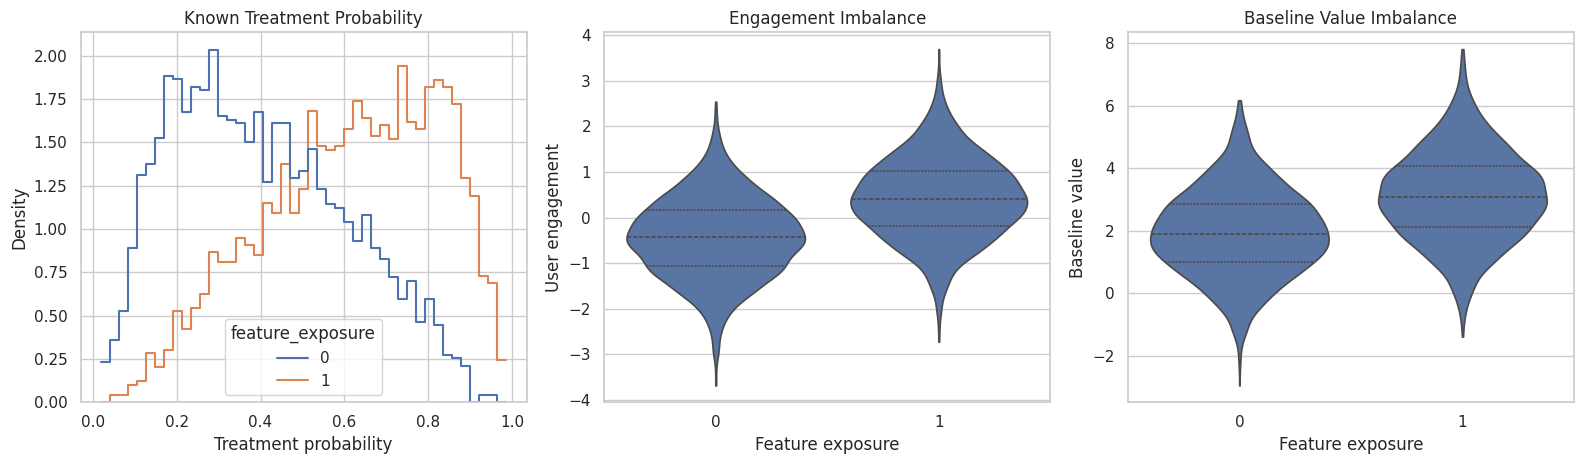

In [4]:
# Build and label the diagnostic visualization for the Confirm Observed Confounding section.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.histplot(
    data=estimator_df,
    x="treatment_probability",
    hue="feature_exposure",
    bins=45,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Known Treatment Probability")
axes[0].set_xlabel("Treatment probability")
axes[0].set_ylabel("Density")

sns.violinplot(data=estimator_df, x="feature_exposure", y="user_engagement", inner="quartile", cut=0, ax=axes[1])
axes[1].set_title("Engagement Imbalance")
axes[1].set_xlabel("Feature exposure")
axes[1].set_ylabel("User engagement")

sns.violinplot(data=estimator_df, x="feature_exposure", y="baseline_value", inner="quartile", cut=0, ax=axes[2])
axes[2].set_title("Baseline Value Imbalance")
axes[2].set_xlabel("Feature exposure")
axes[2].set_ylabel("Baseline value")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_assignment_and_confounding_checks.png", dpi=160, bbox_inches="tight")
plt.show()


The treated and untreated groups differ before treatment. That is why all estimators in this lesson target an adjusted effect rather than a raw difference in means.




## Diagnostics and Interpretation

#### Baseline Imbalance Table

Standardized mean differences summarize baseline imbalance in standard-deviation units. We will use the same metric later to compare raw and weighted balance.

In [5]:
# Define reusable helpers for the Baseline Imbalance Table section.
confounder_cols = ["user_engagement", "prior_sessions", "account_age_weeks", "is_power_user", "baseline_value"]

def weighted_mean(values, weights):
    """
    Idea: Compute a mean that reflects the target population or policy weighting scheme.
    
    Parameters
    ----------
    values : object
        Numeric values being transformed, summarized, or plotted.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Weighted average of the supplied values.
    """
    values = np.asarray(values)
    weights = np.asarray(weights)
    return np.sum(values * weights) / np.sum(weights)

def weighted_var(values, weights):
    """
    Idea: Compute the weighted variance used by the balance or uncertainty diagnostic.
    
    Parameters
    ----------
    values : object
        Numeric values being transformed, summarized, or plotted.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Weighted variance around the supplied or computed weighted mean.
    """
    values = np.asarray(values)
    weights = np.asarray(weights)
    mean = weighted_mean(values, weights)
    return np.sum(weights * (values - mean) ** 2) / np.sum(weights)

def standardized_mean_difference(df, column, treatment_col="feature_exposure", weights=None):
    """
    Idea: Measure covariate imbalance as a treated-control mean difference on a pooled-standard-deviation scale.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    column : object
        Column name selected from the DataFrame for this calculation.
    treatment_col : str
        Name of the treatment or intervention column.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Covariate-balance statistic on a pooled-standard-deviation scale.
    """
    treated_mask = df[treatment_col].to_numpy() == 1
    values = df[column].to_numpy()
    if weights is None:
        treated_values = values[treated_mask]
        control_values = values[~treated_mask]
        pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
        return (treated_values.mean() - control_values.mean()) / pooled_sd

    weights = np.asarray(weights)
    treated_mean = weighted_mean(values[treated_mask], weights[treated_mask])
    control_mean = weighted_mean(values[~treated_mask], weights[~treated_mask])
    treated_var = weighted_var(values[treated_mask], weights[treated_mask])
    control_var = weighted_var(values[~treated_mask], weights[~treated_mask])
    pooled_sd = np.sqrt((treated_var + control_var) / 2)
    return (treated_mean - control_mean) / pooled_sd

raw_balance = pd.DataFrame(
    [
        {"covariate": column, "raw_smd": standardized_mean_difference(estimator_df, column)}
        for column in confounder_cols
    ]
).sort_values("raw_smd", key=lambda s: s.abs(), ascending=False)

raw_balance.to_csv(TABLE_DIR / "04_raw_covariate_balance.csv", index=False)
raw_balance


,covariate,raw_smd
0,user_engagement,0.973071
4,baseline_value,0.830520
3,is_power_user,0.471878
1,prior_sessions,0.390748
2,account_age_weeks,-0.038578


Large absolute values mean exposed and unexposed users differ on that covariate. Matching, stratification, and weighting are all different attempts to reduce the consequences of this imbalance.



### Naive Difference and Outcome Regression

We start with two simple baselines: the naive treated-minus-control difference and an adjusted regression. The adjusted regression controls for the observed common causes named in the graph.

In [6]:
naive_effect = (
    estimator_df.loc[estimator_df["feature_exposure"] == 1, "weekly_value"].mean()
    - estimator_df.loc[estimator_df["feature_exposure"] == 0, "weekly_value"].mean()
)

regression_formula = (
    "weekly_value ~ feature_exposure + user_engagement + prior_sessions "
    "+ account_age_weeks + is_power_user + baseline_value"
)
regression_fit = smf.ols(formula=regression_formula, data=estimator_df).fit()
regression_effect = regression_fit.params["feature_exposure"]
regression_ci = regression_fit.conf_int().loc["feature_exposure"].to_numpy()

regression_baseline = pd.DataFrame(
    [
        {"estimator": "known_true_ate", "estimate": TRUE_ATE, "ci_95_lower": np.nan, "ci_95_upper": np.nan, "description": "Known only because this is a teaching simulation."},
        {"estimator": "naive_difference_in_means", "estimate": naive_effect, "ci_95_lower": np.nan, "ci_95_upper": np.nan, "description": "Unadjusted association; confounding is not blocked."},
        {"estimator": "adjusted_outcome_regression", "estimate": regression_effect, "ci_95_lower": regression_ci[0], "ci_95_upper": regression_ci[1], "description": "Backdoor adjustment through a linear outcome model."},
    ]
)

regression_baseline.to_csv(TABLE_DIR / "04_regression_baseline_estimates.csv", index=False)
regression_baseline


,estimator,estimate,ci_95_lower,ci_95_upper,description
0,known_true_ate,1.650000,NaN,NaN,Known only because this is a teaching simulation.
1,naive_difference_in_means,3.442531,NaN,NaN,Unadjusted association; confounding is not blocked.
2,adjusted_outcome_regression,1.675725,1.600592,1.750857,Backdoor adjustment through a linear outcome model.


The naive difference is inflated because exposed users are stronger at baseline. The adjusted regression moves much closer to the known ATE because it blocks the observed backdoor paths.



### Estimate Propensity Scores

Propensity-score methods first model the probability of treatment given observed common causes. The propensity score compresses multiple confounders into one balancing score.

The code below estimates propensities with logistic regression. We clip very small or very large estimated probabilities to keep manual weighting stable for learning.

In [7]:
X = estimator_df[confounder_cols]
y_treatment = estimator_df["feature_exposure"]

propensity_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, random_state=RANDOM_SEED),
)
propensity_model.fit(X, y_treatment)

estimated_propensity = propensity_model.predict_proba(X)[:, 1]
clipped_propensity = np.clip(estimated_propensity, 0.02, 0.98)

scored_df = estimator_df.copy()
scored_df["estimated_propensity"] = estimated_propensity
scored_df["clipped_propensity"] = clipped_propensity

propensity_summary = pd.DataFrame(
    [
        {"metric": "propensity_model_auc", "value": roc_auc_score(y_treatment, estimated_propensity)},
        {"metric": "estimated_propensity_min", "value": estimated_propensity.min()},
        {"metric": "estimated_propensity_max", "value": estimated_propensity.max()},
        {"metric": "clipped_propensity_min", "value": clipped_propensity.min()},
        {"metric": "clipped_propensity_max", "value": clipped_propensity.max()},
    ]
)

propensity_summary.to_csv(TABLE_DIR / "04_propensity_model_summary.csv", index=False)
propensity_summary


,metric,value
0,propensity_model_auc,0.765052
1,estimated_propensity_min,0.019625
2,estimated_propensity_max,0.984895
3,clipped_propensity_min,0.020000
4,clipped_propensity_max,0.980000


A high AUC means the observed covariates are predictive of treatment. That is not automatically good or bad; it tells us treatment was not random. Very extreme propensities would be a warning for matching and weighting.

### Propensity Overlap

This plot shows whether treated and untreated users occupy similar regions of the estimated propensity-score distribution. Strong overlap makes propensity methods more credible; weak overlap means some units have poor comparisons.

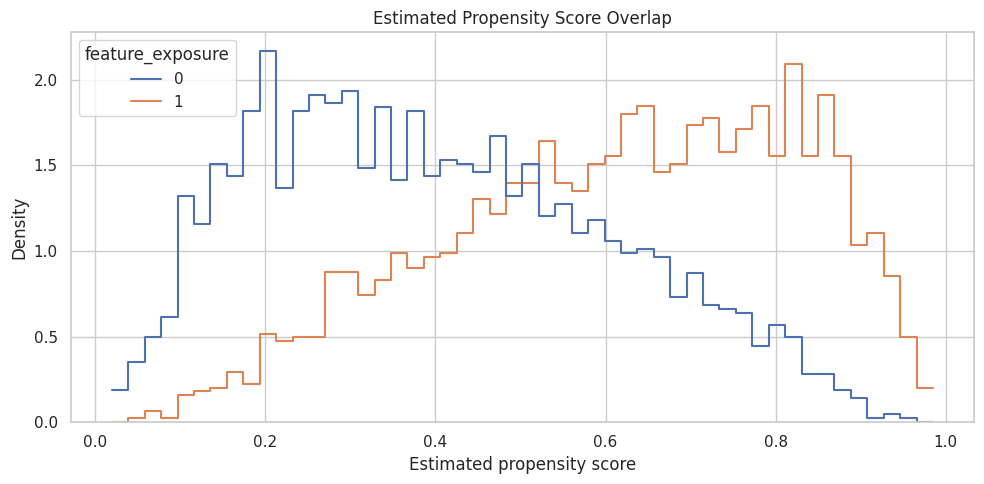

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=scored_df,
    x="estimated_propensity",
    hue="feature_exposure",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=ax,
)
ax.set_title("Estimated Propensity Score Overlap")
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The distributions overlap enough for this worked example, but the tails are worth noticing. The next notebook will go deeper on overlap, common support, and extreme weights.



#### Manual Matching Estimator

Matching creates treated-control comparisons among units with similar propensity scores. Here we use one-nearest-neighbor matching on the estimated propensity score.

To approximate an ATE rather than only an ATT, we match treated units to controls and controls to treated units, then average the implied individual contrasts.

In [9]:
# Fit or evaluate the model objects used in the Manual Matching Estimator section.
treated_df = scored_df.loc[scored_df["feature_exposure"] == 1].copy()
control_df = scored_df.loc[scored_df["feature_exposure"] == 0].copy()

treated_ps = treated_df[["estimated_propensity"]].to_numpy()
control_ps = control_df[["estimated_propensity"]].to_numpy()

control_matcher = NearestNeighbors(n_neighbors=1)
control_matcher.fit(control_ps)
treated_to_control_distance, treated_to_control_index = control_matcher.kneighbors(treated_ps)
matched_control_outcome = control_df["weekly_value"].to_numpy()[treated_to_control_index[:, 0]]
att_estimate = (treated_df["weekly_value"].to_numpy() - matched_control_outcome).mean()

treated_matcher = NearestNeighbors(n_neighbors=1)
treated_matcher.fit(treated_ps)
control_to_treated_distance, control_to_treated_index = treated_matcher.kneighbors(control_ps)
matched_treated_outcome = treated_df["weekly_value"].to_numpy()[control_to_treated_index[:, 0]]
atc_estimate = (matched_treated_outcome - control_df["weekly_value"].to_numpy()).mean()

manual_matching_ate = scored_df["feature_exposure"].mean() * att_estimate + (1 - scored_df["feature_exposure"].mean()) * atc_estimate

matching_summary = pd.DataFrame(
    [
        {"quantity": "ATT from treated-to-control matching", "estimate": att_estimate},
        {"quantity": "ATC from control-to-treated matching", "estimate": atc_estimate},
        {"quantity": "ATE weighted from ATT and ATC", "estimate": manual_matching_ate},
        {"quantity": "Mean treated-to-control propensity distance", "estimate": treated_to_control_distance.mean()},
        {"quantity": "Mean control-to-treated propensity distance", "estimate": control_to_treated_distance.mean()},
    ]
)

matching_summary.to_csv(TABLE_DIR / "04_manual_matching_summary.csv", index=False)
matching_summary


,quantity,estimate
0,ATT from treated-to-control matching,1.725263
1,ATC from control-to-treated matching,1.739918
2,ATE weighted from ATT and ATC,1.732422
3,Mean treated-to-control propensity distance,0.000656
4,Mean control-to-treated propensity distance,0.000495


The matching estimate should be much closer to the true effect than the naive difference. The match-distance rows are simple diagnostics: smaller distances mean treated and untreated units were compared at more similar propensities.

#### Manual Stratification Estimator

Stratification divides the sample into propensity-score bins, compares treated and untreated users inside each bin, and averages those within-bin differences.

This is a useful bridge between matching and weighting because it makes the balancing logic very visible.

In [10]:
# Save the artifacts produced by the Manual Stratification Estimator section.
stratified_df = scored_df.copy()
stratified_df["propensity_stratum"] = pd.qcut(
    stratified_df["estimated_propensity"],
    q=10,
    duplicates="drop",
)

stratum_rows = []
for stratum, group in stratified_df.groupby("propensity_stratum", observed=True):
    treated_group = group.loc[group["feature_exposure"] == 1]
    control_group = group.loc[group["feature_exposure"] == 0]
    if len(treated_group) == 0 or len(control_group) == 0:
        continue
    effect = treated_group["weekly_value"].mean() - control_group["weekly_value"].mean()
    stratum_rows.append(
        {
            "stratum": str(stratum),
            "rows": len(group),
            "treated_rows": len(treated_group),
            "control_rows": len(control_group),
            "mean_propensity": group["estimated_propensity"].mean(),
            "within_stratum_effect": effect,
        }
    )

stratum_effects = pd.DataFrame(stratum_rows)
manual_stratification_ate = np.average(stratum_effects["within_stratum_effect"], weights=stratum_effects["rows"])

stratum_effects.to_csv(TABLE_DIR / "04_stratification_effects_by_stratum.csv", index=False)
print(f"Manual stratification ATE: {manual_stratification_ate:.4f}")
stratum_effects


Manual stratification ATE: 1.7656


,stratum,rows,treated_rows,control_rows,mean_propensity,within_stratum_effect
0,"(0.0186, 0.197]",450,57,393,0.137476,2.065986
1,"(0.197, 0.284]",450,111,339,0.241153,1.683068
2,"(0.284, 0.362]",450,151,299,0.321175,1.436624
3,"(0.362, 0.44]",450,179,271,0.400964,1.465293
4,"(0.44, 0.513]",450,216,234,0.476063,1.782675
5,"(0.513, 0.586]",450,250,200,0.548276,1.844546
6,"(0.586, 0.659]",450,281,169,0.622910,1.614906
7,"(0.659, 0.742]",450,305,145,0.700100,1.792125
8,"(0.742, 0.828]",450,349,101,0.784780,1.706804
9,"(0.828, 0.985]",450,403,47,0.882742,2.264248


Each stratum creates a local treated-versus-control comparison among units with similar estimated propensities. If a stratum has very few treated or control units, the estimate for that stratum becomes fragile.

#### Manual Weighting Estimator

Inverse propensity weighting gives each observed unit a weight based on how surprising its treatment status was. Treated units get weight `1 / e(X)`, and untreated units get weight `1 / (1 - e(X))`.

The code below computes both a plain IPW ATE and a normalized, or self-normalized, IPW estimate.

In [11]:
treatment = scored_df["feature_exposure"].to_numpy()
outcome = scored_df["weekly_value"].to_numpy()
propensity = scored_df["clipped_propensity"].to_numpy()

ipw_weights = treatment / propensity + (1 - treatment) / (1 - propensity)
scored_df["ipw_weight"] = ipw_weights

manual_ipw_ate = np.mean(treatment * outcome / propensity - (1 - treatment) * outcome / (1 - propensity))
manual_normalized_ipw_ate = (
    np.sum(treatment * outcome / propensity) / np.sum(treatment / propensity)
    - np.sum((1 - treatment) * outcome / (1 - propensity)) / np.sum((1 - treatment) / (1 - propensity))
)

weight_summary = pd.DataFrame(
    [
        {"metric": "manual_ipw_ate", "value": manual_ipw_ate},
        {"metric": "manual_normalized_ipw_ate", "value": manual_normalized_ipw_ate},
        {"metric": "mean_ipw_weight", "value": ipw_weights.mean()},
        {"metric": "max_ipw_weight", "value": ipw_weights.max()},
        {"metric": "p99_ipw_weight", "value": np.quantile(ipw_weights, 0.99)},
    ]
)

weight_summary.to_csv(TABLE_DIR / "04_manual_weighting_summary.csv", index=False)
weight_summary


,metric,value
0,manual_ipw_ate,1.802791
1,manual_normalized_ipw_ate,1.753315
2,mean_ipw_weight,1.992565
3,max_ipw_weight,24.004464
4,p99_ipw_weight,7.173259


The plain IPW and normalized IPW estimates can differ because normalization reduces sensitivity to weight scale. The maximum and p99 weights are early warnings about variance; the next notebook will inspect weights more deeply.



#### Covariate Balance After Weighting

A weighting estimator should reduce imbalance in observed confounders. This table compares raw standardized mean differences to IPW-weighted standardized mean differences.

In [12]:
weighted_balance = pd.DataFrame(
    [
        {
            "covariate": column,
            "raw_smd": standardized_mean_difference(scored_df, column),
            "ipw_weighted_smd": standardized_mean_difference(scored_df, column, weights=scored_df["ipw_weight"].to_numpy()),
        }
        for column in confounder_cols
    ]
)
weighted_balance["absolute_raw_smd"] = weighted_balance["raw_smd"].abs()
weighted_balance["absolute_weighted_smd"] = weighted_balance["ipw_weighted_smd"].abs()
weighted_balance = weighted_balance.sort_values("absolute_raw_smd", ascending=False)

weighted_balance.to_csv(TABLE_DIR / "04_weighted_covariate_balance.csv", index=False)
weighted_balance


,covariate,raw_smd,ipw_weighted_smd,absolute_raw_smd,absolute_weighted_smd
0,user_engagement,0.973071,0.022206,0.973071,0.022206
4,baseline_value,0.830520,0.023212,0.830520,0.023212
3,is_power_user,0.471878,0.009249,0.471878,0.009249
1,prior_sessions,0.390748,0.003591,0.390748,0.003591
2,account_age_weeks,-0.038578,-0.017259,0.038578,0.017259


The weighted SMDs should be closer to zero than the raw SMDs. That is the practical balancing purpose of propensity weighting.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->


#### Visualize Balance Before and After Weighting

This plot shows whether inverse propensity weighting reduced covariate imbalance.

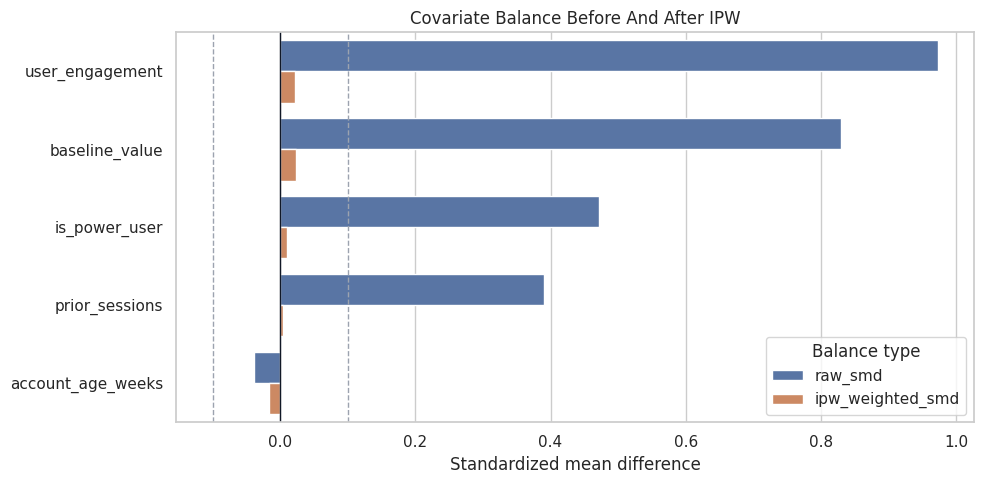

In [13]:
balance_plot_df = weighted_balance.melt(
    id_vars="covariate",
    value_vars=["raw_smd", "ipw_weighted_smd"],
    var_name="balance_type",
    value_name="smd",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=balance_plot_df,
    x="smd",
    y="covariate",
    hue="balance_type",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.1, color="#9ca3af", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#9ca3af", linestyle="--", linewidth=1)
ax.set_title("Covariate Balance Before And After IPW")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("")
ax.legend(title="Balance type")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_weighted_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()


The weighted bars should shrink toward zero. If they did not, we would revisit the propensity model, overlap, or the causal design itself.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->


#### Manual Estimator Comparison

This table gathers the manual estimators into one place and compares them to the known true ATE.

In [14]:
manual_estimator_comparison = pd.DataFrame(
    [
        {"estimator": "known_true_ate", "estimate": TRUE_ATE, "notes": "Simulation benchmark."},
        {"estimator": "naive_difference_in_means", "estimate": naive_effect, "notes": "No adjustment; confounded association."},
        {"estimator": "adjusted_outcome_regression", "estimate": regression_effect, "notes": "Outcome model with observed common causes."},
        {"estimator": "propensity_score_matching", "estimate": manual_matching_ate, "notes": "Nearest-neighbor matching on estimated propensity."},
        {"estimator": "propensity_score_stratification", "estimate": manual_stratification_ate, "notes": "Weighted average of within-stratum effects."},
        {"estimator": "ipw_weighting", "estimate": manual_ipw_ate, "notes": "Plain inverse propensity weighted ATE."},
        {"estimator": "normalized_ipw_weighting", "estimate": manual_normalized_ipw_ate, "notes": "Self-normalized inverse propensity weighted ATE."},
    ]
)
manual_estimator_comparison["absolute_error_vs_true_ate"] = (manual_estimator_comparison["estimate"] - TRUE_ATE).abs()

manual_estimator_comparison.to_csv(TABLE_DIR / "04_manual_estimator_comparison.csv", index=False)
manual_estimator_comparison


,estimator,estimate,notes,absolute_error_vs_true_ate
0,known_true_ate,1.650000,Simulation benchmark.,0.000000
1,naive_difference_in_means,3.442531,No adjustment; confounded association.,1.792531
2,adjusted_outcome_regression,1.675725,Outcome model with observed common causes.,0.025725
3,propensity_score_matching,1.732422,Nearest-neighbor matching on estimated propensity.,0.082422
4,propensity_score_stratification,1.765627,Weighted average of within-stratum effects.,0.115627
5,ipw_weighting,1.802791,Plain inverse propensity weighted ATE.,0.152791
6,normalized_ipw_weighting,1.753315,Self-normalized inverse propensity weighted ATE.,0.103315


The adjusted estimators should be much closer to the known ATE than the naive comparison. They will not be identical because each method uses a different finite-sample approximation.

#### Plot Manual Estimator Comparison

This plot makes the estimator comparison easier to scan. The dashed vertical line marks the known ATE.

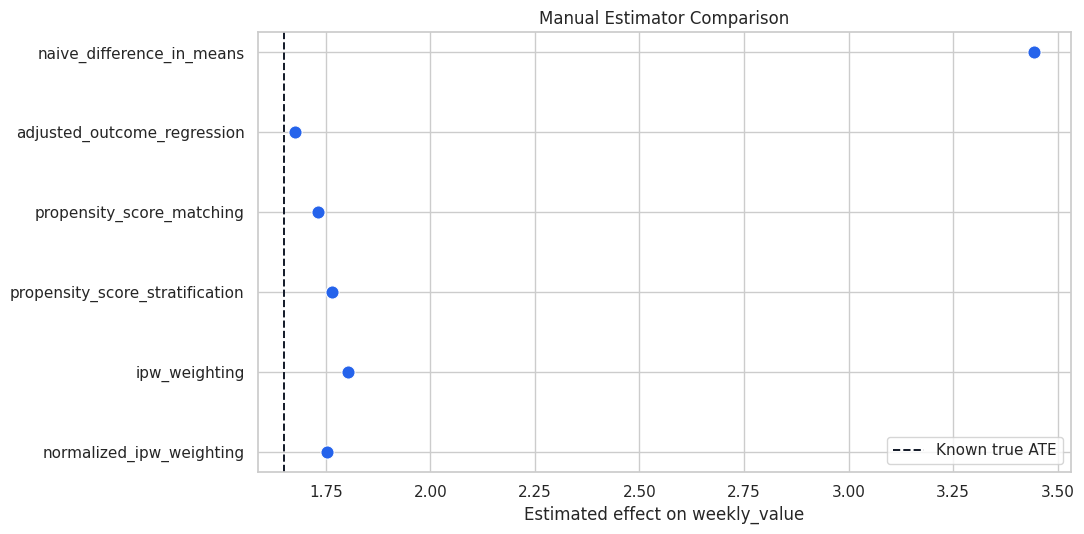

In [15]:
plot_manual = manual_estimator_comparison.query("estimator != 'known_true_ate'").copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.scatterplot(
    data=plot_manual,
    x="estimate",
    y="estimator",
    s=90,
    color="#2563eb",
    ax=ax,
)
ax.axvline(TRUE_ATE, color="#111827", linestyle="--", linewidth=1.4, label="Known true ATE")
ax.set_title("Manual Estimator Comparison")
ax.set_xlabel("Estimated effect on weekly_value")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_manual_estimator_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


Estimator disagreement is not automatically a failure. It is a diagnostic prompt: inspect overlap, model specification, matching quality, and whether all estimators are really targeting the same population estimand.



#### Create the DoWhy Causal Graph

Now we move from manual estimators to DoWhy estimators. The graph states that all baseline variables are common causes of treatment and outcome.

In [16]:
# Define reusable helpers for the Create The DoWhy Causal Graph section.
estimator_edges = [
    ("user_engagement", "feature_exposure"),
    ("user_engagement", "weekly_value"),
    ("prior_sessions", "feature_exposure"),
    ("prior_sessions", "weekly_value"),
    ("account_age_weeks", "feature_exposure"),
    ("account_age_weeks", "weekly_value"),
    ("is_power_user", "feature_exposure"),
    ("is_power_user", "weekly_value"),
    ("baseline_value", "feature_exposure"),
    ("baseline_value", "weekly_value"),
    ("feature_exposure", "weekly_value"),
]

def edges_to_dot(edges):
    """
    Idea: Convert an edge table into DOT graph syntax for DoWhy or Graphviz-style display.
    
    Parameters
    ----------
    edges : object
        Collection of graph edges to draw, compare, or convert into a table.
    
    Returns
    -------
    str
        DOT graph string that can be passed to DoWhy or Graphviz-style renderers.
    """
    lines = ["digraph {"]
    for source, target in edges:
        lines.append(f"    {source} -> {target};")
    lines.append("}")
    return chr(10).join(lines)

estimator_graph = edges_to_dot(estimator_edges)
print(estimator_graph)


digraph {
    user_engagement -> feature_exposure;
    user_engagement -> weekly_value;
    prior_sessions -> feature_exposure;
    prior_sessions -> weekly_value;
    account_age_weeks -> feature_exposure;
    account_age_weeks -> weekly_value;
    is_power_user -> feature_exposure;
    is_power_user -> weekly_value;
    baseline_value -> feature_exposure;
    baseline_value -> weekly_value;
    feature_exposure -> weekly_value;
}


This is the same backdoor graph for every DoWhy estimator below. The graph and estimand stay fixed; only the statistical estimator changes.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Visualize the Estimator Graph

This graph is intentionally simpler than the previous notebook's graph. Every baseline covariate is a common cause, and the treatment points to the outcome.

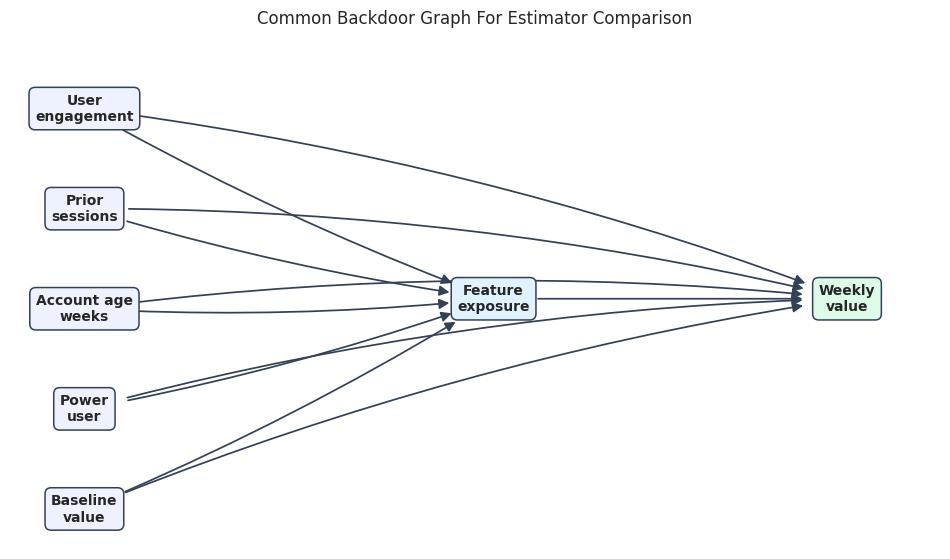

In [17]:
# Build and label the diagnostic visualization for the Visualize The Estimator Graph section.
node_positions = {
    "user_engagement": (0.08, 0.88),
    "prior_sessions": (0.08, 0.68),
    "account_age_weeks": (0.08, 0.48),
    "is_power_user": (0.08, 0.28),
    "baseline_value": (0.08, 0.08),
    "feature_exposure": (0.52, 0.50),
    "weekly_value": (0.90, 0.50),
}

node_labels = {
    "user_engagement": "User\nengagement",
    "prior_sessions": "Prior\nsessions",
    "account_age_weeks": "Account age\nweeks",
    "is_power_user": "Power\nuser",
    "baseline_value": "Baseline\nvalue",
    "feature_exposure": "Feature\nexposure",
    "weekly_value": "Weekly\nvalue",
}

node_colors = {node: "#eef2ff" for node in node_positions}
node_colors["feature_exposure"] = "#e0f2fe"
node_colors["weekly_value"] = "#dcfce7"

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()

for source, target in estimator_edges:
    rad = 0.04 if target == "feature_exposure" else -0.06 if source != "feature_exposure" else 0.0
    ax.annotate(
        "",
        xy=node_positions[target],
        xytext=node_positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.25,
            mutation_scale=15,
            shrinkA=32,
            shrinkB=32,
            connectionstyle=f"arc3,rad={rad}",
        ),
        zorder=1,
    )

for node, (x, y) in node_positions.items():
    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.44", facecolor=node_colors[node], edgecolor="#334155", linewidth=1.1),
        zorder=2,
    )

ax.set_title("Common Backdoor Graph For Estimator Comparison", pad=18)
fig.savefig(FIGURE_DIR / "04_estimator_comparison_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The graph clarifies why all estimators should adjust for the same baseline variables. If the graph changed, the estimand could change too.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


### Identify the Common Estimand with DoWhy

The code below creates a DoWhy `CausalModel` and identifies the backdoor estimand. We inspect the common causes before estimating.

In [18]:
dowhy_df = estimator_df.drop(columns=["treatment_probability"]).copy()

estimator_model = CausalModel(
    data=dowhy_df,
    treatment="feature_exposure",
    outcome="weekly_value",
    graph=estimator_graph,
)

model_metadata = pd.DataFrame(
    [
        {"component": "common_causes_reported_by_DoWhy", "value": ", ".join(estimator_model.get_common_causes())},
        {"component": "instruments_reported_by_DoWhy", "value": ", ".join(estimator_model.get_instruments()) or "none detected"},
        {"component": "effect_modifiers_reported_by_DoWhy", "value": ", ".join(estimator_model.get_effect_modifiers()) or "none detected"},
    ]
)

identified_estimand = estimator_model.identify_effect(proceed_when_unidentifiable=True)

model_metadata.to_csv(TABLE_DIR / "04_dowhy_model_metadata.csv", index=False)
model_metadata


,component,value
0,common_causes_reported_by_DoWhy,"account_age_weeks, user_engagement, is_power_user, prior_sessions, baseline_value"
1,instruments_reported_by_DoWhy,none detected
2,effect_modifiers_reported_by_DoWhy,none detected


The detected common causes match the graph. That is the key checkpoint before comparing estimators.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


### Print the Identified Estimand

The estimand output is verbose, but it is the causal heart of the notebook. It states what must be true before any of the estimators can be read causally.

In [19]:
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|account_age_weeks,user_engagement,is_power_u ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪                                    
↪ ser,prior_sessions,baseline_value])
↪                                    
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,account_age_weeks,user_engagement,is_power_user,prior_sessions,baseline_value,U) = P(weekly_value|feature_exposure,account_age_weeks,user_engagement,is_power_user,prior_sessions,baseline_value)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



The estimand is a backdoor-adjusted average treatment effect. The next cell changes only the estimator, not the causal target.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Run DoWhy Estimators

DoWhy provides estimator names for regression, matching, stratification, and weighting. The code below runs all four against the same identified estimand.

In [20]:
# Save the artifacts produced by the Run DoWhy Estimators section.
dowhy_estimator_specs = [
    ("dowhy_linear_regression", "backdoor.linear_regression"),
    ("dowhy_propensity_score_matching", "backdoor.propensity_score_matching"),
    ("dowhy_propensity_score_stratification", "backdoor.propensity_score_stratification"),
    ("dowhy_propensity_score_weighting", "backdoor.propensity_score_weighting"),
]

dowhy_rows = []
for label, method_name in dowhy_estimator_specs:
    try:
        estimate = estimator_model.estimate_effect(identified_estimand, method_name=method_name)
        dowhy_rows.append(
            {
                "estimator": label,
                "method_name": method_name,
                "estimate": float(estimate.value),
                "absolute_error_vs_true_ate": abs(float(estimate.value) - TRUE_ATE),
                "status": "ok",
            }
        )
    except Exception as exc:
        dowhy_rows.append(
            {
                "estimator": label,
                "method_name": method_name,
                "estimate": np.nan,
                "absolute_error_vs_true_ate": np.nan,
                "status": f"failed: {exc}",
            }
        )

dowhy_estimator_comparison = pd.DataFrame(dowhy_rows)
dowhy_estimator_comparison.to_csv(TABLE_DIR / "04_dowhy_estimator_comparison.csv", index=False)
dowhy_estimator_comparison


,estimator,method_name,estimate,absolute_error_vs_true_ate,status
0,dowhy_linear_regression,backdoor.linear_regression,1.675725,0.025725,ok
1,dowhy_propensity_score_matching,backdoor.propensity_score_matching,1.734642,0.084642,ok
2,dowhy_propensity_score_stratification,backdoor.propensity_score_stratification,1.644848,0.005152,ok
3,dowhy_propensity_score_weighting,backdoor.propensity_score_weighting,1.758190,0.108190,ok


The DoWhy estimates should be near the true effect and much closer than the naive association. Differences across estimators reflect finite-sample behavior and estimator-specific modeling choices.

#### Manual and DoWhy Estimates Side by Side

This table combines the manual and DoWhy estimates. The exact manual and DoWhy values may differ because the internal implementations are limited as identical. They should tell a similar causal story.

In [21]:
manual_for_join = manual_estimator_comparison.assign(source="manual")[["source", "estimator", "estimate", "absolute_error_vs_true_ate"]]
dowhy_for_join = dowhy_estimator_comparison.assign(source="dowhy")[["source", "estimator", "estimate", "absolute_error_vs_true_ate"]]

all_estimator_comparison = pd.concat([manual_for_join, dowhy_for_join], ignore_index=True)
all_estimator_comparison.to_csv(TABLE_DIR / "04_all_estimator_comparison.csv", index=False)
all_estimator_comparison

,source,estimator,estimate,absolute_error_vs_true_ate
0,manual,known_true_ate,1.650000,0.000000
1,manual,naive_difference_in_means,3.442531,1.792531
2,manual,adjusted_outcome_regression,1.675725,0.025725
3,manual,propensity_score_matching,1.732422,0.082422
4,manual,propensity_score_stratification,1.765627,0.115627
5,manual,ipw_weighting,1.802791,0.152791
6,manual,normalized_ipw_weighting,1.753315,0.103315
7,dowhy,dowhy_linear_regression,1.675725,0.025725
8,dowhy,dowhy_propensity_score_matching,1.734642,0.084642
9,dowhy,dowhy_propensity_score_stratification,1.644848,0.005152


The combined table is the main result of the notebook. A good causal workflow asks whether the estimator family changes the conclusion enough to affect the decision.

#### Plot All Estimator Results

This plot compares all estimates against the known true ATE. In real data the true ATE is unavailable, but this plot style is still useful with a reference estimate or sensitivity band.

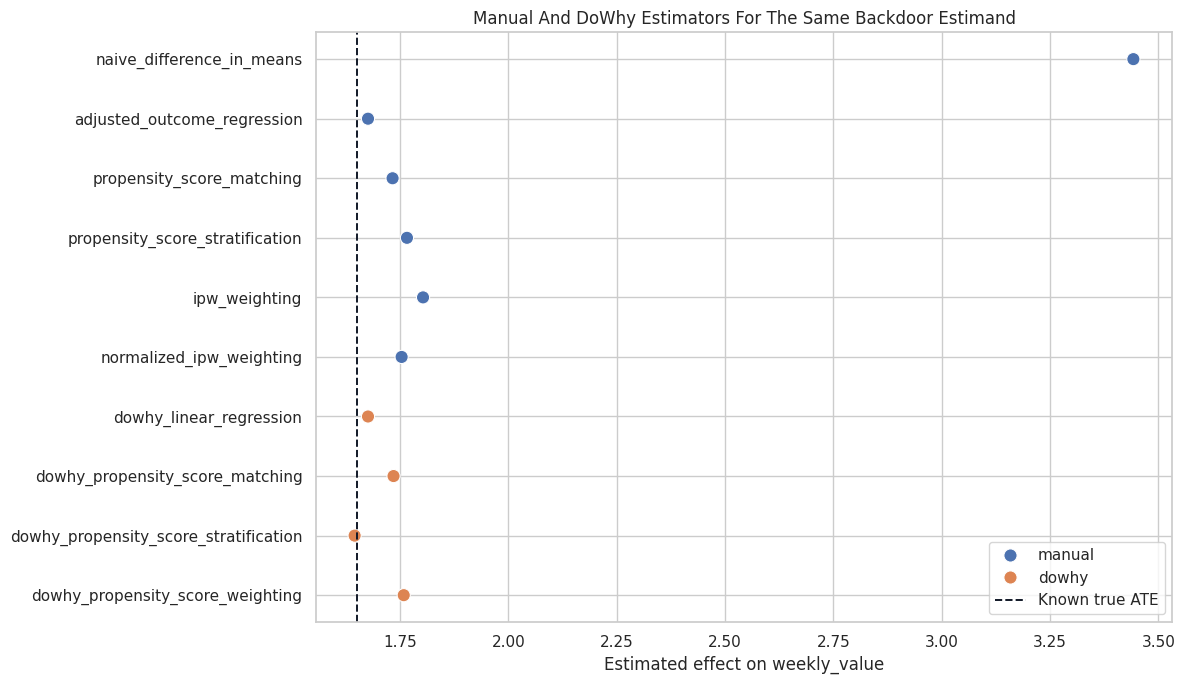

In [22]:
plot_all = all_estimator_comparison.query("estimator != 'known_true_ate'").copy()

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=plot_all,
    x="estimate",
    y="estimator",
    hue="source",
    s=90,
    ax=ax,
)
ax.axvline(TRUE_ATE, color="#111827", linestyle="--", linewidth=1.4, label="Known true ATE")
ax.set_title("Manual And DoWhy Estimators For The Same Backdoor Estimand")
ax.set_xlabel("Estimated effect on weekly_value")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_all_estimator_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The adjusted estimators cluster near the true effect, while the naive estimate is far away. This is the central practical lesson: the causal graph and adjustment logic matter more than the surface sophistication of the estimator.

#### Estimator Choice Guide

This table turns the comparison into practical guidance. It serves a different role than a rigid rulebook. It helps students choose a reasonable first estimator and know what to check next.

| situation | reasonable_start | what_to_check |
| --- | --- | --- |
| Need a transparent first estimate | Outcome regression | Model specification, residual patterns, and whether treatment effect is plausibly constant. |
| Want intuitive treated-control comparisons | Propensity-score matching | Match distances, unmatched regions, and whether matching changes the target population. |
| Want a simple propensity-based diagnostic table | Propensity-score stratification | Treated/control counts and effect stability inside strata. |
| Want a population-level weighted contrast | Propensity-score weighting | Overlap, extreme weights, and weighted covariate balance. |
| Estimators disagree materially | Do not average them blindly | Graph assumptions, overlap, model misspecification, outliers, and target population differences. |


The right response to estimator disagreement is investigation, not automatic ensemble averaging. Estimators are diagnostic lenses on the same causal design.

The table is useful because it compresses the evidence into a form that can be compared, audited, and tied back to the causal question.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Final Summary

This final table gives a compact report-ready summary of the notebook's causal result.

In [23]:
final_summary = pd.DataFrame(
    [
        {"item": "Causal question", "summary": "Average total effect of feature exposure on weekly value."},
        {"item": "Identified estimand", "summary": "Backdoor-adjusted ATE using observed pre-treatment common causes."},
        {"item": "Known true ATE", "summary": f"{TRUE_ATE:.3f}"},
        {"item": "Naive estimate", "summary": f"{naive_effect:.3f}; inflated because treated users are stronger at baseline."},
        {"item": "Adjusted regression estimate", "summary": f"{regression_effect:.3f}"},
        {"item": "Manual matching estimate", "summary": f"{manual_matching_ate:.3f}"},
        {"item": "Manual stratification estimate", "summary": f"{manual_stratification_ate:.3f}"},
        {"item": "Manual normalized IPW estimate", "summary": f"{manual_normalized_ipw_ate:.3f}"},
        {"item": "Main diagnostic", "summary": "Adjusted estimators cluster near the true effect and improve sharply over the naive comparison."},
        {"item": "Main limitation", "summary": "All estimates still depend on the observed-confounding assumption and adequate overlap."},
    ]
)

final_summary.to_csv(TABLE_DIR / "04_final_estimator_summary.csv", index=False)
final_summary


,item,summary
0,Causal question,Average total effect of feature exposure on weekly value.
1,Identified estimand,Backdoor-adjusted ATE using observed pre-treatment common causes.
2,Known true ATE,1.650
3,Naive estimate,3.443; inflated because treated users are stronger at baseline.
4,Adjusted regression estimate,1.676
5,Manual matching estimate,1.732
6,Manual stratification estimate,1.766
7,Manual normalized IPW estimate,1.753
8,Main diagnostic,Adjusted estimators cluster near the true effect and improve sharply over the naive comparison.
9,Main limitation,All estimates still depend on the observed-confounding assumption and adequate overlap.


The final summary separates the causal claim from the estimator mechanics. That is the habit to preserve: report the graph assumptions, the estimand, the estimators, and the diagnostics together.

### Student Exercises

Try these after running the notebook:

1. Increase the strength of confounding in the treatment assignment equation and watch the naive estimate move farther away.
2. Reduce sample size and see which estimators become noisier.
3. Change the number of propensity strata from 10 to 5 or 20.
4. Match on all standardized covariates instead of only the propensity score.
5. Remove clipping in the IPW estimator and inspect the maximum weight.
6. Add a nonlinear outcome term and compare how regression and propensity estimators respond.

### Closing Notes

We have moved through that multiple estimators can target the same identified causal effect. Regression, matching, stratification, and weighting are different ways to operationalize the same backdoor logic.

The next tutorial will focus more deeply on weighting, overlap, common support, and why extreme propensity scores can make causal estimates fragile.